Loading and Preparing the Data

In [1]:
import os
import pandas as pd
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
device = torch.device("cpu") 

#Load Data
#Exclude Columns Related to Data on the Specific Director.
#Want this to be a tool for new directors/producers trying to break in
# So I don't want the model tied to director details
# Also drop the unused genres list column
cols_to_exclude = ["genres","director_name","director_professions","director_birthYear","director_deathYear", "Production budget $"]

target_cols = ["movie_title","Production budget $"]


x = pd.read_csv("movie_statistic_dataset_processed_buckets.csv",usecols=lambda column: column not in cols_to_exclude)
y = pd.read_csv("movie_statistic_dataset_processed_buckets.csv",usecols=target_cols)
# Convert Year String to Int
x['production_date'] = pd.to_datetime(x['production_date']).dt.year.astype(int)

#Set the title as the index
x = x.set_index('movie_title')
y = y.set_index('movie_title')

from sklearn.model_selection import train_test_split
#Split the data
rand_seed=1
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=rand_seed) 

# Scale Data (so consistent with other models)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


Random Forest

In [2]:
from sklearn.ensemble import RandomForestRegressor
est=[]
mse = []
def runRandomF(forest_model, estimators):
    #forest_model = RandomForestRegressor(random_state=rand_seed)
    forest_model.fit(X_train_scaled, y_train)
    print(f"Random Forest Estimators = {estimators}")

    # Predict with the model on the training set and testing set for MSE determination
    Y_train_predict_forest = forest_model.predict(X_train_scaled)
    Y_test_predict_forest = forest_model.predict(X_test_scaled)

    # MSE Test
    mse_test_forest = mean_squared_error(y_test, Y_test_predict_forest)
    r_test_forest = r2_score(y_test, Y_test_predict_forest)
    print(f'MSE TEST: {mse_test_forest}')
    print(f'R^2 TEST: {r_test_forest}')

    #MSE TRAINING
    mse_train_forest = mean_squared_error(y_train, Y_train_predict_forest)
    r_train_forest = r2_score(y_train, Y_train_predict_forest)
    print(f'MSE TRAIN: {mse_train_forest}')
    print(f'R^2 TRAIN: {r_train_forest}')
    
    est.append(estimators)
    mse.append(mse_test_forest)

model = RandomForestRegressor()
runRandomF(model, 100)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 100
MSE TEST: 560941254652403.2
R^2 TEST: 0.7433154378683426
MSE TRAIN: 76438564358323.66
R^2 TRAIN: 0.9630350667739479


In [3]:
model5 = RandomForestRegressor(n_estimators=150)
runRandomF(model5, 150)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 150
MSE TEST: 566056136460721.2
R^2 TEST: 0.740974887612083
MSE TRAIN: 75496545180905.28
R^2 TRAIN: 0.9634906179251665


In [4]:
model4 = RandomForestRegressor(n_estimators=200)
runRandomF(model4, 200)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 200
MSE TEST: 557093005045518.56
R^2 TEST: 0.7450763820975714
MSE TRAIN: 73250342846004.66
R^2 TRAIN: 0.964576859144096


In [5]:
model8 = RandomForestRegressor(n_estimators=250)
runRandomF(model8, 250)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 250
MSE TEST: 553266894192169.7
R^2 TEST: 0.7468271957182733
MSE TRAIN: 73883793144652.98
R^2 TRAIN: 0.9642705288488043


In [6]:
model9 = RandomForestRegressor(n_estimators=275)
runRandomF(model9, 275)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 275
MSE TEST: 556039185075081.2
R^2 TEST: 0.7455586060656498
MSE TRAIN: 74347791749492.05
R^2 TRAIN: 0.9640461437156083


In [7]:
model6 = RandomForestRegressor(n_estimators=300)
runRandomF(model6, 300)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 300
MSE TEST: 551393958988720.44
R^2 TEST: 0.7476842436686799
MSE TRAIN: 74871107627797.92
R^2 TRAIN: 0.9637930733360152


In [8]:
model11 = RandomForestRegressor(n_estimators=350)
runRandomF(model11, 350)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 350
MSE TEST: 552216862619694.4
R^2 TEST: 0.747307686130005
MSE TRAIN: 74357818773005.55
R^2 TRAIN: 0.9640412947462726


In [9]:
model12 = RandomForestRegressor(n_estimators=375)
runRandomF(model12, 375)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 375
MSE TEST: 554702446484350.7
R^2 TEST: 0.7461702925069666
MSE TRAIN: 73442727858207.56
R^2 TRAIN: 0.9644838236561918


In [10]:
model10 = RandomForestRegressor(n_estimators=400)
runRandomF(model10, 400)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 400
MSE TEST: 557264179500169.9
R^2 TEST: 0.744998053325038
MSE TRAIN: 74976277503147.16
R^2 TRAIN: 0.9637422142251421


In [11]:
model2 = RandomForestRegressor(n_estimators=500)
runRandomF(model2, 500)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 500
MSE TEST: 559051554117882.0
R^2 TEST: 0.7441801575698096
MSE TRAIN: 73274134782834.45
R^2 TRAIN: 0.9645653535989093


In [12]:
model7 = RandomForestRegressor(n_estimators=800)
runRandomF(model6, 800)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 800
MSE TEST: 552465946726917.44
R^2 TEST: 0.7471937061999032
MSE TRAIN: 73728423108752.86
R^2 TRAIN: 0.9643456642604985


In [13]:
model3 = RandomForestRegressor(n_estimators=1000)
runRandomF(model3, 1000)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Estimators = 1000
MSE TEST: 556961628829362.44
R^2 TEST: 0.7451364993491354
MSE TRAIN: 73521163831629.28
R^2 TRAIN: 0.9644458927957106


Plotting the Variations

 Min Index5
Estimators of Min Testing MSE: 300


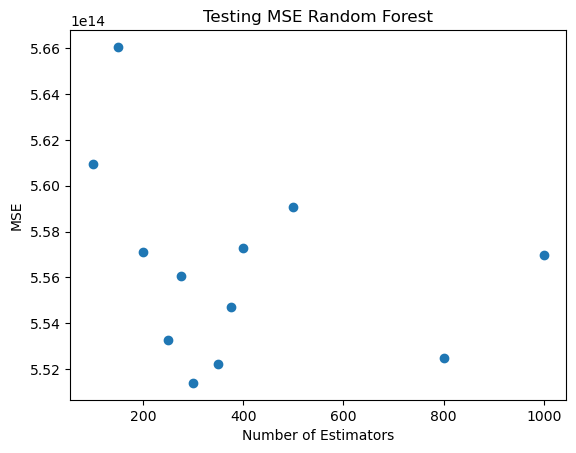

In [14]:

min_testing_index = mse.index(min(mse))
print(f' Min Index{min_testing_index}')
print(f'Estimators of Min Testing MSE: {est[min_testing_index]}')
plt.scatter(est,mse)
plt.xlabel("Number of Estimators")
plt.ylabel("MSE")
plt.title(f"Testing MSE Random Forest")
plt.savefig("Plots/Random Forest Testing MSE")
plt.show()
